In [1]:
import pandas as pd
import matplotlib as plt
import numpy as np

In [2]:
labs = pd.read_csv("new dataset/new_labs_relevant_in_lookback.csv")
vitals = pd.read_csv("new dataset/new_vitals_relevant_in_lookback.csv")

labs.shape, vitals.shape


((128831, 14), (216884, 14))

### Analysis of datasets

In [3]:
print(labs.columns)
print(vitals.columns)

print(labs.lab_result_text_val.unique())

Index(['Unnamed: 0', 'patient_id', 'encounter_id', 'code_system', 'code',
       'date', 'lab_result_num_val', 'lab_result_text_val', 'units_of_measure',
       'derived_by_TriNetX', 'source_id', 'code_desc', 'lookback_start',
       'lookback_end'],
      dtype='object')
Index(['Unnamed: 0', 'patient_id', 'encounter_id', 'code_system', 'code',
       'date', 'value', 'text_value', 'units_of_measure', 'derived_by_TriNetX',
       'source_id', 'code_desc', 'lookback_start', 'lookback_end'],
      dtype='object')
[nan]


In [4]:
def missing_values_summary(df, df_name):
    print(f"\n===== MISSING VALUES: {df_name} =====")
    missing = df.isnull().sum()
    percent = (missing / len(df)) * 100
    summary = pd.DataFrame({
        "missing_count": missing,
        "missing_percent": percent.round(2)
    })
    print(summary)

missing_values_summary(labs, "LABS")
missing_values_summary(vitals, "VITALS")


===== MISSING VALUES: LABS =====
                     missing_count  missing_percent
Unnamed: 0                       0              0.0
patient_id                       0              0.0
encounter_id                     0              0.0
code_system                      0              0.0
code                             0              0.0
date                             0              0.0
lab_result_num_val               0              0.0
lab_result_text_val         128831            100.0
units_of_measure                 0              0.0
derived_by_TriNetX               0              0.0
source_id                        0              0.0
code_desc                        0              0.0
lookback_start                   0              0.0
lookback_end                     0              0.0

===== MISSING VALUES: VITALS =====
                    missing_count  missing_percent
Unnamed: 0                      0              0.0
patient_id                      0              0

In [5]:
labs_nunique = labs.nunique()
vitals_nunique = vitals.nunique()

print("\n=== LABS UNIQUE VALUES ===")
print(labs_nunique) 
print("\n=== VITALS UNIQUE VALUES ===")
print(vitals_nunique)



=== LABS UNIQUE VALUES ===
Unnamed: 0             128831
patient_id               2030
encounter_id             5218
code_system                 1
code                       14
date                     2044
lab_result_num_val       9403
lab_result_text_val         0
units_of_measure            8
derived_by_TriNetX          2
source_id                   2
code_desc                  14
lookback_start           1019
lookback_end             1019
dtype: int64

=== VITALS UNIQUE VALUES ===
Unnamed: 0            216884
patient_id              2370
encounter_id           10003
code_system                1
code                       3
date                    2221
value                    258
text_value                 0
units_of_measure           2
derived_by_TriNetX         1
source_id                  1
code_desc                  3
lookback_start          1096
lookback_end            1096
dtype: int64


In [4]:
labs_patients = set(labs['patient_id'].unique())
vitals_patients = set(vitals['patient_id'].unique())

print("Number of unique patients in labs dataset:", len(labs_patients))
print("Number of unique patients in vitals dataset:", len(vitals_patients))

common_patients = labs_patients.intersection(vitals_patients)
print("Number of patients present in BOTH LABS and VITALS:", len(common_patients))

labs_only = labs_patients - vitals_patients
vitals_only = vitals_patients - labs_patients

print("Number of patients ONLY in LABS:", len(labs_only))
print("Number of patients ONLY in VITALS:", len(vitals_only))


Number of unique patients in labs dataset: 2030
Number of unique patients in vitals dataset: 2370
Number of patients present in BOTH LABS and VITALS: 1996
Number of patients ONLY in LABS: 34
Number of patients ONLY in VITALS: 374


In [31]:
labs_counts = labs.groupby('patient_id').size()
vitals_counts = vitals.groupby('patient_id').size()

print("\n=== LABS MEASUREMENTS PER PATIENT STATISTICS ===")
print(labs_counts.describe())
print("\n=== VITALS MEASUREMENTS PER PATIENT STATISTICS ===")
print(vitals_counts.describe())



=== LABS MEASUREMENTS PER PATIENT STATISTICS ===
count    2030.000000
mean       63.463547
std        93.436708
min         1.000000
25%        18.000000
50%        35.000000
75%        71.000000
max      1039.000000
dtype: float64

=== VITALS MEASUREMENTS PER PATIENT STATISTICS ===
count    2370.000000
mean       91.512236
std       164.496081
min         2.000000
25%        11.000000
50%        38.000000
75%       110.000000
max      2853.000000
dtype: float64


In [33]:
specific_value_count = labs['patient_id'].value_counts()['BQuT']
print("Number of lab measurements for patient 'BQuT':", specific_value_count)

specific_value_count = vitals['patient_id'].value_counts()['BQuT']
print("Number of lab measurements for patient 'BQuT':", specific_value_count)

Number of lab measurements for patient 'BQuT': 923
Number of lab measurements for patient 'BQuT': 1736


### Concatenating two datasets labs and vitals

In [5]:

labs_small = labs[[
    'patient_id',
    'date',
    'code',
    'code_desc',
    'lab_result_num_val'
]].copy()

labs_small = labs_small.rename(
    columns={'lab_result_num_val': 'value'}
)

labs_small['source'] = 'lab'


vitals_small = vitals[[
    'patient_id',
    'date',
    'code',
    'code_desc',
    'value'
]].copy()

vitals_small['source'] = 'vital'


# 3) Combine labs + vitals
combined = pd.concat([labs_small, vitals_small], ignore_index=True)


combined['date'] = pd.to_datetime(combined['date'], errors='coerce')

# 5) Sorting
combined = combined.sort_values(
    ['patient_id', 'date']
).reset_index(drop=True)

combined.head()


,patient_id,date,code,code_desc,value,source
0,BA#G,2023-10-12,1975-2,Bilirubin.total [Mass/volume] in Serum or Plasma,1.30,lab
1,BA#G,2023-10-12,2075-0,Chloride [Moles/volume] in Serum or Plasma,106.00,lab
2,BA#G,2023-10-12,2160-0,Creatinine [Mass/volume] in Serum or Plasma,1.54,lab
3,BA#G,2023-10-12,2345-7,Glucose [Mass/volume] in Serum or Plasma,140.00,lab
4,BA#G,2023-10-12,2823-3,Potassium [Moles/volume] in Serum or Plasma,4.40,lab


In [35]:
combined.shape

(345715, 6)

In [6]:
combined_unique = combined['patient_id'].nunique()
print("Number of unique patients in combined dataset:", combined_unique)

Number of unique patients in combined dataset: 2404


In [7]:
print("Total rows:", combined.shape[0])
print("Labs rows:", (combined['source'] == 'lab').sum())
print("Vitals rows:", (combined['source'] == 'vital').sum())

print("Missing values in value column:")
combined['value'].isna().sum()


Total rows: 345715
Labs rows: 128831
Vitals rows: 216884
Missing values in value column:


np.int64(0)

### Building time-series dataset

In [8]:
def build_event_timeseries(labs: pd.DataFrame, vitals: pd.DataFrame) -> pd.DataFrame:


    labs_small = labs[['patient_id', 'date', 'code', 'code_desc', 'lab_result_num_val']].copy()
    labs_small = labs_small.rename(columns={'lab_result_num_val': 'value'})
    labs_small['source'] = 'lab'

    vitals_small = vitals[['patient_id', 'date', 'code', 'code_desc', 'value']].copy()
    vitals_small['source'] = 'vital'


    #Combine
    events = pd.concat([labs_small, vitals_small], ignore_index=True)

    # 4) Clean types
    events['date'] = pd.to_datetime(events['date'], errors='coerce')
    events['value'] = pd.to_numeric(events['value'], errors='coerce')

    # 5) Drop rows missing core fields
    events = events.dropna(subset=['patient_id', 'date', 'code', 'value'])

    # 6) Sort 
    events = events.sort_values(['patient_id', 'date']).reset_index(drop=True)

    # 7) Add time gap between consecutive events per patient
    events['delta_days'] = (
        events.groupby('patient_id')['date']
              .diff()
              .dt.days
              .fillna(0)
              .clip(lower=0)
              .astype(int)
    )

    return events


events = build_event_timeseries(labs, vitals)


print("Events shape:", events.shape)
print("Labs rows:", (events['source'] == 'lab').sum())
print("Vitals rows:", (events['source'] == 'vital').sum())
print("Unique patients:", events['patient_id'].nunique())
print("Unique codes:", events['code'].nunique())
print("Missing values in value column:", events['value'].isna().sum())

# View one patient's time series (example)
some_pid = events['patient_id'].iloc[0]
print("\nExample patient:", some_pid)
print(events[events['patient_id'] == some_pid].head(20))




Events shape: (345715, 7)
Labs rows: 128831
Vitals rows: 216884
Unique patients: 2404
Unique codes: 17
Missing values in value column: 0

Example patient: BA#G
   patient_id       date     code  \
0        BA#G 2023-10-12   1975-2   
1        BA#G 2023-10-12   2075-0   
2        BA#G 2023-10-12   2160-0   
3        BA#G 2023-10-12   2345-7   
4        BA#G 2023-10-12   2823-3   
5        BA#G 2023-10-12   2951-2   
6        BA#G 2023-10-12   3094-0   
7        BA#G 2023-10-12  33762-6   
8        BA#G 2023-10-12  67151-1   
9        BA#G 2023-10-12  67151-1   
10       BA#G 2023-10-12  67151-1   
11       BA#G 2023-10-12    718-7   
12       BA#G 2023-10-12    718-7   
13       BA#G 2023-10-12  33914-3   
14       BA#G 2023-10-12   8462-4   
15       BA#G 2023-10-12   8462-4   
16       BA#G 2023-10-12   8462-4   
17       BA#G 2023-10-12   8462-4   
18       BA#G 2023-10-12   8462-4   
19       BA#G 2023-10-12   8462-4   

                                            code_desc      val

In [9]:
# events = output from the time-series construction code

timestamps_per_patient = (
    events
    .groupby('patient_id')
    .size()
    .rename('num_timestamps')
)
timestamps_per_patient.to_csv("timestamps_per_patient.csv", index=True)
print(timestamps_per_patient.head())
print("\n=== Timestamps Per Patient Statistics ===")
print(timestamps_per_patient.describe())


patient_id
BA#G    134
BA#K     33
BA#N     57
BA#P    166
BA#Q     33
Name: num_timestamps, dtype: int64

=== Timestamps Per Patient Statistics ===
count    2404.000000
mean      143.808236
std       243.019196
min         1.000000
25%        24.000000
50%        68.000000
75%       171.000000
max      3282.000000
Name: num_timestamps, dtype: float64


In [10]:
import pandas as pd


combined = combined[['patient_id', 'date', 'code', 'code_desc', 'value']].copy()

combined['date'] = pd.to_datetime(combined['date'], errors='coerce')
combined['value'] = pd.to_numeric(combined['value'], errors='coerce')

#  Drop rows missing key fields
combined = combined.dropna(subset=['patient_id', 'date', 'code', 'value'])

#  Sort by patient then time
combined = combined.sort_values(['patient_id', 'date']).reset_index(drop=True)

# Add time gap between events per patient
combined['delta_days'] = (
    combined.groupby('patient_id')['date']
            .diff()
            .dt.days
            .fillna(0)
            .clip(lower=0)
            .astype(int)
)

combined.head(10)


,patient_id,date,code,code_desc,value,delta_days
0,BA#G,2023-10-12,1975-2,Bilirubin.total [Mass/volume] in Serum or Plasma,1.30,0
1,BA#G,2023-10-12,2075-0,Chloride [Moles/volume] in Serum or Plasma,106.00,0
2,BA#G,2023-10-12,2160-0,Creatinine [Mass/volume] in Serum or Plasma,1.54,0
3,BA#G,2023-10-12,2345-7,Glucose [Mass/volume] in Serum or Plasma,140.00,0
4,BA#G,2023-10-12,2823-3,Potassium [Moles/volume] in Serum or Plasma,4.40,0
5,BA#G,2023-10-12,2951-2,Sodium [Moles/volume] in Serum or Plasma,141.00,0
6,BA#G,2023-10-12,3094-0,Urea nitrogen [Mass/volume] in Serum or Plasma,24.00,0
7,BA#G,2023-10-12,33762-6,Natriuretic peptide.B prohormone N-Terminal [M...,2014.00,0
8,BA#G,2023-10-12,67151-1,Troponin T.cardiac [Mass/volume] in Serum or P...,18.00,0
9,BA#G,2023-10-12,67151-1,Troponin T.cardiac [Mass/volume] in Serum or P...,25.00,0


In [46]:
combined.shape

(345715, 6)

In [47]:
combined.code.nunique()

17

In [48]:
combined.columns

Index(['patient_id', 'date', 'code', 'code_desc', 'value', 'delta_days'], dtype='object')

In [ ]:
print(combined[combined['code'] == '8867-4'].shape[0])

1413


##### Deleting rows with code = 8867-4 (Heart rate vital measurement) as suggested by Grace

In [11]:
rows_to_drop_indices = combined[combined['code'] == '8867-4'].index
print("Number of rows to drop with code '8867-4':", len(rows_to_drop_indices))
combined.drop(rows_to_drop_indices, inplace=True)

Number of rows to drop with code '8867-4': 1413


In [51]:
print("Columns after dropping code '8867-4':", combined.columns.tolist())

Columns after dropping code '8867-4': ['patient_id', 'date', 'code', 'code_desc', 'value', 'delta_days']


In [52]:
print("Updated shape after dropping code '8867-4':", combined.shape)

Updated shape after dropping code '8867-4': (344302, 6)


#### Normalizing code vocab and values for each code group

In [12]:
unique_codes = combined['code'].astype(str).unique()
print("Unique codes in the combined dataset:",unique_codes)

# Group by code and list the unique descriptions associated with each
unique_mapping = combined.groupby('code')['code_desc'].unique()

for code, desc in unique_mapping.items():
    print(f"Code: {code} | Description(s): {', '.join(map(str, desc))}")


code2id = {c: i+1 for i, c in enumerate(unique_codes)}  
combined['code_id'] = combined['code'].astype(str).map(code2id).astype(int)

print("Unique codes:", len(code2id))
combined[['code', 'code_id']].head(10)


Unique codes in the combined dataset: ['1975-2' '2075-0' '2160-0' '2345-7' '2823-3' '2951-2' '3094-0' '33762-6'
 '67151-1' '718-7' '33914-3' '8462-4' '8480-6' '4548-4' '1751-7' '6690-2']
Code: 1751-7 | Description(s): Albumin [Mass/volume] in Serum or Plasma
Code: 1975-2 | Description(s): Bilirubin.total [Mass/volume] in Serum or Plasma
Code: 2075-0 | Description(s): Chloride [Moles/volume] in Serum or Plasma
Code: 2160-0 | Description(s): Creatinine [Mass/volume] in Serum or Plasma
Code: 2345-7 | Description(s): Glucose [Mass/volume] in Serum or Plasma
Code: 2823-3 | Description(s): Potassium [Moles/volume] in Serum or Plasma
Code: 2951-2 | Description(s): Sodium [Moles/volume] in Serum or Plasma
Code: 3094-0 | Description(s): Urea nitrogen [Mass/volume] in Serum or Plasma
Code: 33762-6 | Description(s): Natriuretic peptide.B prohormone N-Terminal [Mass/volume] in Serum or Plasma
Code: 33914-3 | Description(s): Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum

,code,code_id
0,1975-2,1
1,2075-0,2
2,2160-0,3
3,2345-7,4
4,2823-3,5
5,2951-2,6
6,3094-0,7
7,33762-6,8
8,67151-1,9
9,67151-1,9


In [13]:

reference_df = combined[['code', 'code_desc']].drop_duplicates().copy()

# Map the code_id to this reference table
# We use the code2id dictionary you already created
reference_df['code_id'] = reference_df['code'].astype(str).map(code2id)

reference_df = reference_df.sort_values('code_id')

print("Code Mapping Reference:")
print(reference_df[['code_id', 'code_desc', 'code']].to_string(index=False))

Code Mapping Reference:
 code_id                                                                                                               code_desc    code
       1                                                                        Bilirubin.total [Mass/volume] in Serum or Plasma  1975-2
       2                                                                              Chloride [Moles/volume] in Serum or Plasma  2075-0
       3                                                                             Creatinine [Mass/volume] in Serum or Plasma  2160-0
       4                                                                                Glucose [Mass/volume] in Serum or Plasma  2345-7
       5                                                                             Potassium [Moles/volume] in Serum or Plasma  2823-3
       6                                                                                Sodium [Moles/volume] in Serum or Plasma  2951-2
       7         

In [54]:
combined.head()

,patient_id,date,code,code_desc,value,delta_days,code_id
0,BA#G,2023-10-12,1975-2,Bilirubin.total [Mass/volume] in Serum or Plasma,1.30,0,1
1,BA#G,2023-10-12,2075-0,Chloride [Moles/volume] in Serum or Plasma,106.00,0,2
2,BA#G,2023-10-12,2160-0,Creatinine [Mass/volume] in Serum or Plasma,1.54,0,3
3,BA#G,2023-10-12,2345-7,Glucose [Mass/volume] in Serum or Plasma,140.00,0,4
4,BA#G,2023-10-12,2823-3,Potassium [Moles/volume] in Serum or Plasma,4.40,0,5


In [27]:
combined.code_desc.unique()

array(['Bilirubin.total [Mass/volume] in Serum or Plasma',
       'Chloride [Moles/volume] in Serum or Plasma',
       'Creatinine [Mass/volume] in Serum or Plasma',
       'Glucose [Mass/volume] in Serum or Plasma',
       'Potassium [Moles/volume] in Serum or Plasma',
       'Sodium [Moles/volume] in Serum or Plasma',
       'Urea nitrogen [Mass/volume] in Serum or Plasma',
       'Natriuretic peptide.B prohormone N-Terminal [Mass/volume] in Serum or Plasma',
       'Troponin T.cardiac [Mass/volume] in Serum or Plasma by High sensitivity method',
       'Hemoglobin [Mass/volume] in Blood',
       'Glomerular filtration rate/1.73 sq M.predicted [Volume Rate/Area] in Serum or Plasma by Creatinine-based formula (MDRD)',
       'Blood Pressure Diastolic', 'Blood Pressure Systolic',
       'Hemoglobin A1c/Hemoglobin.total in Blood',
       'Albumin [Mass/volume] in Serum or Plasma',
       'Leukocytes [#/volume] in Blood by Automated count'], dtype=object)

In [14]:
combined.shape

(344302, 7)

#### Filtering the patients based on the number of visits they make to the hospital

Idea : Consider the patients who visits the hospital more frequently as outliers.

a) Calculating unique visits of each patient \
b) Calculate the percentile table \
c) Analyse the table and consider only the top x% for the transformer model and delete the other rows 

Instead of considering all the time stamps for the model, only count the number of days a patient visited the hospital to get his lab/vital measurement done.

Let's say if the timestamp number for the patient on a particular day is 10 different type of test/vitals after aggregation, we only consider it as 1 and not 10.

In [15]:
# Count unique visit days (hospitals visits) per patient
visit_stats = combined.groupby('patient_id')['date'].nunique().to_frame(name='Number_of_Visits')
total_patients = len(visit_stats)

#  GENERATE PERCENTILE TABLE FOR DECISION MAKING 
percentile_levels = range(75, 101, 1)
percentile_values = np.percentile(visit_stats['Number_of_Visits'], list(percentile_levels))

# Calculate how many patients fall into each percentile bucket
patient_counts = [(visit_stats['Number_of_Visits'] <= val).sum() for val in percentile_values]

percentile_df = pd.DataFrame({
    'Percentile': [f"{p}%" for p in percentile_levels],
    'Max_Unique_Visit_Days': percentile_values.astype(int),
    'Patient_Count': patient_counts,
    'Cumulative_Coverage': [f"{(count / total_patients * 100):.2f}%" for count in patient_counts]
})

print("\n--- Full Percentile Distribution with Patient Counts ---")
print(percentile_df.to_string(index=False))


# Define the 97th percentile threshold
p97_threshold = int(np.percentile(visit_stats['Number_of_Visits'], 97))

# Identify the valid patient IDs (the bottom 97%)
valid_patient_ids = visit_stats[visit_stats['Number_of_Visits'] <= p97_threshold].index

# Create the new updated dataset by removing the top 3%
combined_filtered = combined[combined['patient_id'].isin(valid_patient_ids)].copy()

patients_removed = total_patients - len(valid_patient_ids)
rows_removed = len(combined) - len(combined_filtered)

print(f"\n--- FILTERING RESULTS (Target: 97th Percentile) ---")
print(f"P97 Cutoff Threshold: {p97_threshold} unique visit days")
print(f"Original Patients:    {total_patients}")
print(f"Patients Removed:     {patients_removed} (Top 3% Outliers)")
print(f"Patients Remaining:    {len(valid_patient_ids)}")
print(f"Original Dataset Rows: {len(combined):,}")
print(f"Rows Removed:         {rows_removed:,}")
print(f"Updated Dataset Rows: {len(combined_filtered):,}")

# Display the first few rows of your clean dataset
display(combined_filtered.head(10))


--- Full Percentile Distribution with Patient Counts ---
Percentile  Max_Unique_Visit_Days  Patient_Count Cumulative_Coverage
       75%                     11           1861              77.41%
       76%                     11           1861              77.41%
       77%                     11           1861              77.41%
       78%                     12           1917              79.74%
       79%                     12           1917              79.74%
       80%                     13           1985              82.57%
       81%                     13           1985              82.57%
       82%                     13           1985              82.57%
       83%                     14           2046              85.11%
       84%                     14           2046              85.11%
       85%                     14           2046              85.11%
       86%                     15           2086              86.77%
       87%                     16           2

,patient_id,date,code,code_desc,value,delta_days,code_id
0,BA#G,2023-10-12,1975-2,Bilirubin.total [Mass/volume] in Serum or Plasma,1.30,0,1
1,BA#G,2023-10-12,2075-0,Chloride [Moles/volume] in Serum or Plasma,106.00,0,2
2,BA#G,2023-10-12,2160-0,Creatinine [Mass/volume] in Serum or Plasma,1.54,0,3
3,BA#G,2023-10-12,2345-7,Glucose [Mass/volume] in Serum or Plasma,140.00,0,4
4,BA#G,2023-10-12,2823-3,Potassium [Moles/volume] in Serum or Plasma,4.40,0,5
5,BA#G,2023-10-12,2951-2,Sodium [Moles/volume] in Serum or Plasma,141.00,0,6
6,BA#G,2023-10-12,3094-0,Urea nitrogen [Mass/volume] in Serum or Plasma,24.00,0,7
7,BA#G,2023-10-12,33762-6,Natriuretic peptide.B prohormone N-Terminal [M...,2014.00,0,8
8,BA#G,2023-10-12,67151-1,Troponin T.cardiac [Mass/volume] in Serum or P...,18.00,0,9
9,BA#G,2023-10-12,67151-1,Troponin T.cardiac [Mass/volume] in Serum or P...,25.00,0,9


In [16]:

# Collapse multiple records per day into 4 stats
combined_daily = combined_filtered.groupby(['patient_id', 'date', 'code', 'code_id'], as_index=False).agg(
    val_mean=('value', 'mean'),
    val_max=('value', 'max'),
    val_min=('value', 'min'),
    val_count=('value', 'count')
)

In [17]:

# Normalize all 4 stats at once per code_id using transform (no merges needed)
stats_cols = ['val_mean', 'val_max', 'val_min', 'val_count']
for col in stats_cols:
    # This calculates (x - mean) / std for every group automatically
    combined_daily[f'{col}_norm'] = combined_daily.groupby('code_id')[col].transform(
        lambda x: (x - x.mean()) / (x.std() if x.std() > 0 else 1)
    ).fillna(0)


In [18]:

# Calculate time gaps using .diff()
combined_daily = combined_daily.sort_values(['patient_id', 'date'])
combined_daily['delta_days'] = (
    combined_daily.groupby('patient_id')['date']
    .diff()
    .dt.days.fillna(0)
    .astype(int)
)

In [19]:

sample_pid = combined_filtered[combined_filtered.duplicated(['patient_id', 'date', 'code'])]['patient_id'].iloc[0]

print(f"Reduction: {len(combined_filtered)} rows -> {len(combined_daily)} rows")

print(f"\n--- [BEFORE] Raw Records (Sample {sample_pid}) ---")
display(combined_filtered[combined_filtered['patient_id'] == sample_pid].sort_values(['date', 'code']).head(20))

print(f"\n--- [AFTER] Hybrid Daily Summary (Sample {sample_pid}) ---")
cols = ['date', 'code', 'code_id', 'val_max', 'val_mean', 'val_min', 'val_count', 'val_mean_norm', 'val_max_norm', 'val_min_norm', 'val_count_norm', 'delta_days']
display(combined_daily[combined_daily['patient_id'] == sample_pid][cols].head(20))

Reduction: 271510 rows -> 111223 rows

--- [BEFORE] Raw Records (Sample BA#G) ---


,patient_id,date,code,code_desc,value,delta_days,code_id
0,BA#G,2023-10-12,1975-2,Bilirubin.total [Mass/volume] in Serum or Plasma,1.3000,0,1
1,BA#G,2023-10-12,2075-0,Chloride [Moles/volume] in Serum or Plasma,106.0000,0,2
2,BA#G,2023-10-12,2160-0,Creatinine [Mass/volume] in Serum or Plasma,1.5400,0,3
3,BA#G,2023-10-12,2345-7,Glucose [Mass/volume] in Serum or Plasma,140.0000,0,4
4,BA#G,2023-10-12,2823-3,Potassium [Moles/volume] in Serum or Plasma,4.4000,0,5
5,BA#G,2023-10-12,2951-2,Sodium [Moles/volume] in Serum or Plasma,141.0000,0,6
6,BA#G,2023-10-12,3094-0,Urea nitrogen [Mass/volume] in Serum or Plasma,24.0000,0,7
7,BA#G,2023-10-12,33762-6,Natriuretic peptide.B prohormone N-Terminal [M...,2014.0000,0,8
13,BA#G,2023-10-12,33914-3,Glomerular filtration rate/1.73 sq M.predicted...,45.8536,0,11
8,BA#G,2023-10-12,67151-1,Troponin T.cardiac [Mass/volume] in Serum or P...,18.0000,0,9



--- [AFTER] Hybrid Daily Summary (Sample BA#G) ---


,date,code,code_id,val_max,val_mean,val_min,val_count,val_mean_norm,val_max_norm,val_min_norm,val_count_norm,delta_days
0,2023-10-12,1975-2,1,1.3000,1.300000,1.3000,1,0.547006,0.537507,0.556124,-0.310564,0
1,2023-10-12,2075-0,2,106.0000,106.000000,106.0000,1,0.529167,0.511375,0.543330,-0.387425,0
2,2023-10-12,2160-0,3,1.5400,1.540000,1.5400,1,1.714292,1.669193,1.746935,-0.387662,0
3,2023-10-12,2345-7,4,140.0000,140.000000,140.0000,1,0.088034,0.031692,0.142122,-0.341473,0
4,2023-10-12,2823-3,5,4.4000,4.400000,4.4000,1,0.345018,0.285530,0.388546,-0.397144,0
5,2023-10-12,2951-2,6,141.0000,141.000000,141.0000,1,0.280952,0.267836,0.292737,-0.388166,0
6,2023-10-12,3094-0,7,24.0000,24.000000,24.0000,1,0.318901,0.293933,0.342715,-0.389067,0
7,2023-10-12,33762-6,8,2014.0000,2014.000000,2014.0000,1,-0.274496,-0.274923,-0.274041,-0.206559,0
8,2023-10-12,33914-3,11,45.8536,45.853600,45.8536,1,-1.109802,-1.118935,-1.082481,-0.481090,0
9,2023-10-12,67151-1,9,25.0000,21.666667,18.0000,3,-0.251652,-0.235534,-0.238423,1.086665,0


In [20]:
combined_daily = combined_daily.sort_values(['patient_id', 'date']).reset_index(drop=True)
combined_daily.head()


,patient_id,date,code,code_id,val_mean,val_max,val_min,val_count,val_mean_norm,val_max_norm,val_min_norm,val_count_norm,delta_days
0,BA#G,2023-10-12,1975-2,1,1.30,1.30,1.30,1,0.547006,0.537507,0.556124,-0.310564,0
1,BA#G,2023-10-12,2075-0,2,106.00,106.00,106.00,1,0.529167,0.511375,0.543330,-0.387425,0
2,BA#G,2023-10-12,2160-0,3,1.54,1.54,1.54,1,1.714292,1.669193,1.746935,-0.387662,0
3,BA#G,2023-10-12,2345-7,4,140.00,140.00,140.00,1,0.088034,0.031692,0.142122,-0.341473,0
4,BA#G,2023-10-12,2823-3,5,4.40,4.40,4.40,1,0.345018,0.285530,0.388546,-0.397144,0


In [21]:
combined_daily.drop(columns=['code', 'val_max', 'val_mean', 'val_min', 'val_count'], inplace=True)
combined_daily.head()


,patient_id,date,code_id,val_mean_norm,val_max_norm,val_min_norm,val_count_norm,delta_days
0,BA#G,2023-10-12,1,0.547006,0.537507,0.556124,-0.310564,0
1,BA#G,2023-10-12,2,0.529167,0.511375,0.543330,-0.387425,0
2,BA#G,2023-10-12,3,1.714292,1.669193,1.746935,-0.387662,0
3,BA#G,2023-10-12,4,0.088034,0.031692,0.142122,-0.341473,0
4,BA#G,2023-10-12,5,0.345018,0.285530,0.388546,-0.397144,0


In [80]:
combined_daily.shape

(111223, 8)

In [22]:
combined_daily['code_id'].nunique()

16

In [23]:
combined_daily['patient_id'].nunique()

2336

#### Sequence Length Analysis

Padding to 2000+ wastes memory and computation
Most information is in recent history
To balance information and efficiency:
 - Compute 95th percentile (P95) of sequence lengths
 - Truncate each patient to the most recent P95 events

This keeps almost all data while removing extreme outliers.

In [24]:
row_counts_before = combined_filtered.groupby('patient_id').size()
print("\n=== Rows Per Patient Statistics (Before Aggregation) ===")
print(row_counts_before.describe())



=== Rows Per Patient Statistics (Before Aggregation) ===
count    2336.000000
mean      116.228596
std       142.272799
min         1.000000
25%        23.000000
50%        64.000000
75%       155.250000
max      1076.000000
dtype: float64


In [25]:
# Count rows per patient in your new aggregated table
row_counts_after = combined_daily.groupby('patient_id').size()
row_counts_after.head(20)

print("\n=== Rows Per Patient Statistics (After Aggregation) ===")
print(row_counts_after.describe())



=== Rows Per Patient Statistics (After Aggregation) ===
count    2336.000000
mean       47.612586
std        46.921039
min         1.000000
25%        14.000000
50%        33.000000
75%        64.000000
max       288.000000
dtype: float64


In [26]:

percentile_range = range(75, 101)
percentile_values = np.percentile(row_counts_after, percentile_range)

print("Percentile Distribution (75th to 100th):")
for p, val in zip(percentile_range, percentile_values):
    print(f"P{p}: {int(val)}")

Percentile Distribution (75th to 100th):
P75: 64
P76: 66
P77: 68
P78: 71
P79: 73
P80: 75
P81: 78
P82: 81
P83: 84
P84: 87
P85: 91
P86: 95
P87: 100
P88: 104
P89: 107
P90: 112
P91: 115
P92: 122
P93: 128
P94: 136
P95: 147
P96: 156
P97: 172
P98: 194
P99: 217
P100: 288


In [27]:
max_len = int(percentile_values[-6])
print(f"Chosen max sequence length (P95): {max_len}")

Chosen max sequence length (P95): 147


In [28]:
# Combine the 4 normalized stats into a single vector (list) per row
feature_cols = ['val_mean_norm', 'val_max_norm', 'val_min_norm', 'val_count_norm']
combined_daily['feature_vector'] = combined_daily[feature_cols].values.tolist()


In [29]:
# Group into sequences per patient
seq_df = (
    combined_daily.groupby('patient_id')
    .agg(
        code_ids=('code_id', list),
        values=('feature_vector', list), 
        deltas=('delta_days', list)
    )
    .reset_index()
)

In [30]:
# Truncate sequences to your P95 length (max_len)

seq_df['code_ids'] = seq_df['code_ids'].apply(lambda x: x[-max_len:])
seq_df['values']   = seq_df['values'].apply(lambda x: x[-max_len:])
seq_df['deltas']   = seq_df['deltas'].apply(lambda x: x[-max_len:])

In [31]:

sample_val = seq_df['values'].iloc[0][0]
print(f"Total Patients: {len(seq_df)}")
print(f"Example feature vector for one event: {sample_val}")
print(f"Vector length: {len(sample_val)} (Should be 4: Mean, Max, Min, Count)")
seq_df.head()

Total Patients: 2336
Example feature vector for one event: [0.5470057655360814, 0.5375067869761395, 0.5561244723931871, -0.31056372926704773]
Vector length: 4 (Should be 4: Mean, Max, Min, Count)


,patient_id,code_ids,values,deltas
0,BA#G,"[1, 2, 3, 4, 5, 6, 7, 8, 11, 9, 10, 12, 13, 1,...","[[0.5470057655360814, 0.5375067869761395, 0.55...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
1,BA#K,"[2, 3, 4, 5, 6, 7, 11, 9, 10, 12, 13, 2, 3, 4,...","[[0.13583014810119443, 0.11792988474020139, 0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ..."
2,BA#N,"[12, 13, 15, 1, 2, 3, 4, 5, 6, 7, 11, 16, 10, ...","[[0.7218805023244356, 0.06378163104114976, 1.0...","[0, 0, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 27, 0..."
3,BA#P,"[1, 2, 3, 4, 5, 6, 7, 11, 9, 10, 12, 13, 2, 3,...","[[-0.422845549842705, -0.42349982801963926, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
4,BA#Q,"[12, 13, 1, 1, 2, 3, 4, 5, 6, 7, 11, 12, 13, 1...","[[-1.2911443007747019, -0.7436544088037363, -0...","[0, 0, 1, 66, 0, 0, 0, 0, 0, 0, 0, 6, 0, 90, 0..."


In [32]:
print(f"Length of values list for first patient: {len(seq_df['values'].iloc[0])} ")
print(f"Length of code_ids list for first patient: {len(seq_df['code_ids'].iloc[0])} ")
print(f"Length of deltas list for first patient: {len(seq_df['deltas'].iloc[0])} ")

Length of values list for first patient: 46 
Length of code_ids list for first patient: 46 
Length of deltas list for first patient: 46 


In [33]:
seq_df['seq_len_after'] = seq_df['code_ids'].apply(len)
seq_df['seq_len_after'].describe()


count    2336.000000
mean       45.491866
std        40.330295
min         1.000000
25%        14.000000
50%        33.000000
75%        64.000000
max       147.000000
Name: seq_len_after, dtype: float64

In [34]:
seq_df.head(5)

,patient_id,code_ids,values,deltas,seq_len_after
0,BA#G,"[1, 2, 3, 4, 5, 6, 7, 8, 11, 9, 10, 12, 13, 1,...","[[0.5470057655360814, 0.5375067869761395, 0.55...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",46
1,BA#K,"[2, 3, 4, 5, 6, 7, 11, 9, 10, 12, 13, 2, 3, 4,...","[[0.13583014810119443, 0.11792988474020139, 0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",22
2,BA#N,"[12, 13, 15, 1, 2, 3, 4, 5, 6, 7, 11, 16, 10, ...","[[0.7218805023244356, 0.06378163104114976, 1.0...","[0, 0, 12, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 27, 0...",47
3,BA#P,"[1, 2, 3, 4, 5, 6, 7, 11, 9, 10, 12, 13, 2, 3,...","[[-0.422845549842705, -0.42349982801963926, -0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...",83
4,BA#Q,"[12, 13, 1, 1, 2, 3, 4, 5, 6, 7, 11, 12, 13, 1...","[[-1.2911443007747019, -0.7436544088037363, -0...","[0, 0, 1, 66, 0, 0, 0, 0, 0, 0, 0, 6, 0, 90, 0...",27


Extract sequences into Python lists

In [46]:
patient_ids = seq_df['patient_id'].tolist()
codes_list  = seq_df['code_ids'].tolist()
vals_list   = seq_df['values'].tolist()
dlt_list    = seq_df['deltas'].tolist()
print("Example patient_id:", patient_ids[2])
print("Example code_ids:", codes_list[2])
print("Example values:", vals_list[2])
print("Example deltas:", dlt_list[2]
      )

Example patient_id: BA#N
Example code_ids: [12, 13, 15, 1, 2, 3, 4, 5, 6, 7, 11, 16, 10, 12, 13, 16, 10, 12, 13, 15, 1, 2, 3, 4, 5, 6, 7, 11, 16, 10, 12, 13, 15, 1, 2, 3, 4, 5, 6, 7, 8, 11, 14, 16, 10, 12, 13]
Example values: [[0.7218805023244356, 0.06378163104114976, 1.0671514405831615, -0.6972524311171939], [-0.7119316509478052, -1.01394787100641, -0.19309838876240706, -0.6984400207203401], [-0.3284318595751973, -0.3386533501844171, -0.3160091257617693, -0.47041341315010493], [-0.13189015522906913, -0.13519784352090564, -0.12835797860408832, -0.31056372926704773], [0.13583014810119443, 0.11792988474020139, 0.15295806159414924, -0.3874251953123813], [-1.0304557311882068, -1.0409109639228, -1.012845165388253, -0.3876617208080519], [-0.7767267214996745, -0.7471493461769495, -0.7574969075616318, -0.34147256554914684], [0.345018242534746, 0.28552997624763016, 0.38854621493654246, -0.39714370118949], [0.05066152852528559, 0.03729772998818584, 0.06397497115470123, -0.3881658675752264], [-0.

#### Convert Patient-Level Event Sequences into Transformer-Ready Batch Tensors

Patient histories are **irregular** and **vary in length**.  
Since Transformers operate on **fixed-size tensors**, sequences within each batch must be padded to a common length.

In this step:
- Patient event sequences are padded using a special value (`0`)
- An **attention mask** is constructed to distinguish:
  - real clinical events (`1`)
  - padding tokens (`0`)

The attention mask ensures that padded time steps **do not influence** the Transformer’s attention or learning process, allowing correct modeling of longitudinal EHR data.



In [83]:
import torch

num_patients = len(codes_list)
pad_code = 0
pad_delta = 0

lengths = torch.tensor([len(x) for x in codes_list], dtype=torch.long)
L_max = int(lengths.max().item())


# Shape: (Total Patients, Max Length, Features)
code_id = torch.full((num_patients, L_max), pad_code, dtype=torch.long)
value   = torch.zeros((num_patients, L_max, 4), dtype=torch.float)
delta   = torch.full((num_patients, L_max), pad_delta, dtype=torch.long)

# Fill tensors with ALL real data
for i in range(num_patients):
    l = len(codes_list[i])
    code_id[i, :l] = torch.tensor(codes_list[i], dtype=torch.long)
    value[i, :l]   = torch.tensor(vals_list[i], dtype=torch.float)
    delta[i, :l]   = torch.tensor(dlt_list[i], dtype=torch.long)


attn_mask = (code_id != pad_code).long()

print("Shapes:")
print("code_id:", code_id.shape)
print("value:", value.shape)
print("delta:", delta.shape)

print("attn_mask:", attn_mask.shape)

print("\nCheck lengths vs mask sums (first 10):")
print("lengths:", lengths[:10].tolist())
print("mask sums:", attn_mask.sum(dim=1)[:10].tolist())




Shapes:
code_id: torch.Size([2336, 147])
value: torch.Size([2336, 147, 4])
delta: torch.Size([2336, 147])
attn_mask: torch.Size([2336, 147])

Check lengths vs mask sums (first 10):
lengths: [46, 22, 47, 83, 27, 6, 23, 12, 46, 4]
mask sums: [46, 22, 47, 83, 27, 6, 23, 12, 46, 4]


In [84]:
import torch

#  Take a small real slice (2 patients from your actual data)
sample_batch_vals = vals_list[:2] 

# Get their actual lengths
len_0 = len(sample_batch_vals[0])
len_1 = len(sample_batch_vals[1])
max_l = max(len_0, len_1)

print("--- ACTUAL DATA: BEFORE PADDING ---")
print(f"Patient 0 sequence length: {len_0}")
print(f"Patient 1 sequence length: {len_1}")
print(f"First 2 events for Patient 0: {sample_batch_vals[0][:2]}")

#  Create the 3D Tensor [Batch=2, Time=max_l, Features=4]
actual_value_tensor = torch.zeros((2, max_l, 4))

for i, p_vals in enumerate(sample_batch_vals):
    length = len(p_vals)
    actual_value_tensor[i, :length, :] = torch.tensor(p_vals, dtype=torch.float32)

print("\n--- ACTUAL DATA: AFTER PADDING (The 3D Block) ---")
print(f"Tensor Shape: {actual_value_tensor.shape}")


shorter_idx = 0 if len_0 < len_1 else 1
split_point = min(len_0, len_1)

print(f"\nShowing Patient {shorter_idx} near the padding boundary (Index {split_point}):")
# We show 2 real events followed by 2 padded events
print(actual_value_tensor[shorter_idx, split_point-2 : split_point+2])

# 4. The Attention Mask for these actual patients
actual_mask = (actual_value_tensor.abs().sum(dim=-1) != 0).long()
print("\n--- ACTUAL ATTENTION MASK (Tail end) ---")
print(actual_mask[shorter_idx, split_point-2 : split_point+2])

--- ACTUAL DATA: BEFORE PADDING ---
Patient 0 sequence length: 46
Patient 1 sequence length: 22
First 2 events for Patient 0: [[0.5470057655360814, 0.5375067869761395, 0.5561244723931871, -0.31056372926704773], [0.5291672082573464, 0.5113745838789517, 0.5433302001211001, -0.3874251953123813]]

--- ACTUAL DATA: AFTER PADDING (The 3D Block) ---
Tensor Shape: torch.Size([2, 46, 4])

Showing Patient 1 near the padding boundary (Index 22):
tensor([[-0.2242, -0.2298, -0.0926, -0.2615],
        [ 0.4716,  0.3683,  0.1866, -0.2665],
        [ 0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000]])

--- ACTUAL ATTENTION MASK (Tail end) ---
tensor([1, 1, 0, 0])


#### Transformer model architecture

In [85]:
import torch
import torch.nn as nn

class TimeSeriesTransformer(nn.Module):
    def __init__(self, num_codes, d_model=128, nhead=8, num_layers=4, 
                 dim_ff=256, dropout=0.1, max_delta_days=365):
        super().__init__()
        
        self.max_delta_days = max_delta_days

        # --- 1. INPUT PROJECTION & EMBEDDINGS ---
       
        self.code_emb = nn.Embedding(num_codes + 1, d_model, padding_idx=0)
        
        # delta_days: temporal embedding for time gaps
        self.delta_emb = nn.Embedding(max_delta_days + 1, d_model)
        
        # values: project the 4-dim hybrid features [mean, max, min, count] to d_model
        self.val_proj = nn.Linear(4, d_model)

        # Normalization and Dropout for stability
        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        # Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Reconstruction head for pre-training (predict the 4 values back from the model's internal representation)
        
        self.reconstruction_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 4) 
        )

        self.code_head = nn.Sequential(
    nn.Linear(d_model, d_model),
    nn.GELU(),
    nn.Linear(d_model, num_codes + 1)
)

    def forward(self, code_ids, values, delta_days, attn_mask):
        """
        Args:
            code_ids:   (Batch, Seq) - The clinical test IDs
            values:     (Batch, Seq, 4) - [mean, max, min, count]
            delta_days: (Batch, Seq) - Days since last event
            attn_mask:  (Batch, Seq) - 1 for real data, 0 for padding
        """
        # Clamp time gaps to the max embedding range
        delta_days = torch.clamp(delta_days, 0, self.max_delta_days)

        # Combine all features into a single concept vector per time step
        # Shape: (Batch, Seq, d_model)
        x = (
            self.code_emb(code_ids) + 
            self.delta_emb(delta_days) + 
            self.val_proj(values)
        )
        
        # Apply normalization and dropout
        x = self.dropout(self.layer_norm(x))

      
        padding_mask = (attn_mask == 0)

        
        # h shape: (Batch, Seq, d_model)
        h = self.encoder(x, src_key_padding_mask=padding_mask)

        # Reconstruct the 4 values (for pre-training loss)
        # predictions shape: (Batch, Seq, 4)
        predictions = self.reconstruction_head(h)
        pred_codes = self.code_head(h)
        return predictions, pred_codes, h


In [86]:
num_codes = len(code2id)  
model = TimeSeriesTransformer(num_codes=num_codes)
model


TimeSeriesTransformer(
  (code_emb): Embedding(17, 128, padding_idx=0)
  (delta_emb): Embedding(366, 128)
  (val_proj): Linear(in_features=4, out_features=128, bias=True)
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (reconstr

#### Self supervised learning (Masked value reconstruction)

Randomly selected 15% of the real (non-padding) measurements in a patient's history. For these selected positions, set the input value to 0.0, essentially "hiding" the truth from the model which then forces the model to look at the other 85% of the patient's history to "guess" what the hidden 15% should be.

#### Experiment - 1 : Masking both code_ids and values at different positions
##### Helps preserve partial context while learning multimodal relationships

In [87]:
from torch.utils.data import random_split, DataLoader
import torch

total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train patients:", len(train_dataset))
print("Validation patients:", len(val_dataset))

Train patients: 1868
Validation patients: 468


In [88]:

total_patients = value.shape[0] 
print(f"Total patients in the tensor: {total_patients}")


dataset = HeartFailureDataset(code_id, value, delta, attn_mask)

loader = DataLoader(dataset, batch_size=32, shuffle=True) 

print(f"Updated Loader: {len(loader)} batches found.")

Total patients in the tensor: 2336
Updated Loader: 73 batches found.


In [ ]:
import torch
import torch.nn.functional as F
import random
from torch.utils.data import random_split, DataLoader


# Train / Validation Split

total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train patients:", len(train_dataset))
print("Validation patients:", len(val_dataset))

Train patients: 1868
Validation patients: 468


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

value_mask_prob = 0.15
code_mask_prob = 0.10
code_loss_weight = 0.1
epochs = 20

best_val_loss = float("inf")

print(f"Starting Pre-training on {device}...")

Starting Pre-training on cpu...


In [ ]:
train_losses = []
val_losses = []

train_value_losses = []
val_value_losses = []

train_code_losses = []
val_code_losses = []

print(f"Starting Pre-training on {device}...")

Starting Pre-training on cpu...


In [ ]:

# Training Loop

for epoch in range(epochs):

    model.train()

    total_loss = 0
    total_value_loss = 0
    total_code_loss = 0

    for batch in train_loader:

        code_id, value, delta, attn_mask = [b.to(device) for b in batch]

        B, L = code_id.shape

        value_mask = torch.zeros((B, L), dtype=torch.bool, device=device)
        code_mask = torch.zeros((B, L), dtype=torch.bool, device=device)

        for b in range(B):

            valid_idx = torch.where(attn_mask[b] == 1)[0].tolist()

            if len(valid_idx) == 0:
                continue

            # Value mask
            k_value = max(1, int(len(valid_idx) * value_mask_prob))
            value_chosen = random.sample(valid_idx, k_value)

            value_mask[b, value_chosen] = True

            # Code mask
            remaining_idx = list(set(valid_idx) - set(value_chosen))

            if len(remaining_idx) > 0:

                k_code = max(1, int(len(valid_idx) * code_mask_prob))
                k_code = min(k_code, len(remaining_idx))

                code_chosen = random.sample(remaining_idx, k_code)

                code_mask[b, code_chosen] = True

        # Masked inputs
        value_in = value.clone()
        code_in = code_id.clone()

        value_in[value_mask] = 0.0
        code_in[code_mask] = 0

        optimizer.zero_grad()

        pred_vals, pred_codes, h = model(
            code_in,
            value_in,
            delta,
            attn_mask
        )

        # Losses
        loss_value = F.mse_loss(
            pred_vals[value_mask],
            value[value_mask]
        )

        loss_code = F.cross_entropy(
            pred_codes[code_mask],
            code_id[code_mask]
        )

        loss = loss_value + code_loss_weight * loss_code

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()
        total_value_loss += loss_value.item()
        total_code_loss += loss_code.item()

    avg_train_loss = total_loss / len(train_loader)
    avg_train_value_loss = total_value_loss / len(train_loader)
    avg_train_code_loss = total_code_loss / len(train_loader)

    
    # VALIDATION
  
    model.eval()

    val_total_loss = 0
    val_value_loss = 0
    val_code_loss = 0

    with torch.no_grad():

        for batch in val_loader:

            code_id, value, delta, attn_mask = [b.to(device) for b in batch]

            B, L = code_id.shape

            value_mask = torch.zeros((B, L), dtype=torch.bool, device=device)
            code_mask = torch.zeros((B, L), dtype=torch.bool, device=device)

            for b in range(B):

                valid_idx = torch.where(attn_mask[b] == 1)[0].tolist()

                if len(valid_idx) == 0:
                    continue

                k_value = max(1, int(len(valid_idx) * value_mask_prob))
                value_chosen = random.sample(valid_idx, k_value)

                value_mask[b, value_chosen] = True

                remaining_idx = list(set(valid_idx) - set(value_chosen))

                if len(remaining_idx) > 0:

                    k_code = max(1, int(len(valid_idx) * code_mask_prob))
                    k_code = min(k_code, len(remaining_idx))

                    code_chosen = random.sample(remaining_idx, k_code)

                    code_mask[b, code_chosen] = True

            value_in = value.clone()
            code_in = code_id.clone()

            value_in[value_mask] = 0.0
            code_in[code_mask] = 0

            pred_vals, pred_codes, h = model(
                code_in,
                value_in,
                delta,
                attn_mask
            )

            loss_value = F.mse_loss(
                pred_vals[value_mask],
                value[value_mask]
            )

            loss_code = F.cross_entropy(
                pred_codes[code_mask],
                code_id[code_mask]
            )

            val_loss = loss_value + code_loss_weight * loss_code

            val_total_loss += val_loss.item()
            val_value_loss += loss_value.item()
            val_code_loss += loss_code.item()

    avg_val_loss = val_total_loss / len(val_loader)
    avg_val_value_loss = val_value_loss / len(val_loader)
    avg_val_code_loss = val_code_loss / len(val_loader)

    
    # Store for plots
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    train_value_losses.append(avg_train_value_loss)
    val_value_losses.append(avg_val_value_loss)

    train_code_losses.append(avg_train_code_loss)
    val_code_losses.append(avg_val_code_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Train Value: {avg_train_value_loss:.6f} | "
        f"Train Code: {avg_train_code_loss:.6f} || "
        f"Val Loss: {avg_val_loss:.6f} | "
        f"Val Value: {avg_val_value_loss:.6f} | "
        f"Val Code: {avg_val_code_loss:.6f}"
    )

    # Save best model
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            "best_aim1_transformer.pt"
        )

        print("Saved best model")

print("Pre-training Finished!")
print(f"Best Validation Loss: {best_val_loss:.6f}")


Epoch [1/20] Train Loss: 1.211813 | Train Value: 0.943728 | Train Code: 2.680853 || Val Loss: 1.165941 | Val Value: 0.908602 | Val Code: 2.573383
Saved best model
Epoch [2/20] Train Loss: 1.102725 | Train Value: 0.851742 | Train Code: 2.509825 || Val Loss: 1.743663 | Val Value: 1.498342 | Val Code: 2.453212
Epoch [3/20] Train Loss: 1.112876 | Train Value: 0.871720 | Train Code: 2.411561 || Val Loss: 1.098738 | Val Value: 0.860974 | Val Code: 2.377638
Saved best model
Epoch [4/20] Train Loss: 1.087368 | Train Value: 0.852194 | Train Code: 2.351734 || Val Loss: 1.013875 | Val Value: 0.780731 | Val Code: 2.331435
Saved best model
Epoch [5/20] Train Loss: 1.020334 | Train Value: 0.788869 | Train Code: 2.314650 || Val Loss: 1.011374 | Val Value: 0.781018 | Val Code: 2.303558
Saved best model
Epoch [6/20] Train Loss: 1.061588 | Train Value: 0.834787 | Train Code: 2.268011 || Val Loss: 0.968467 | Val Value: 0.743334 | Val Code: 2.251327
Saved best model
Epoch [7/20] Train Loss: 0.916818 | Tra

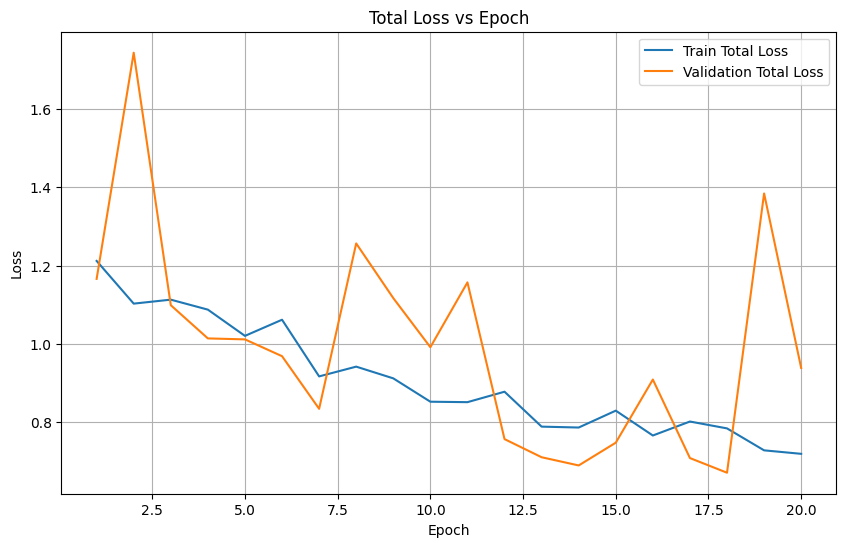

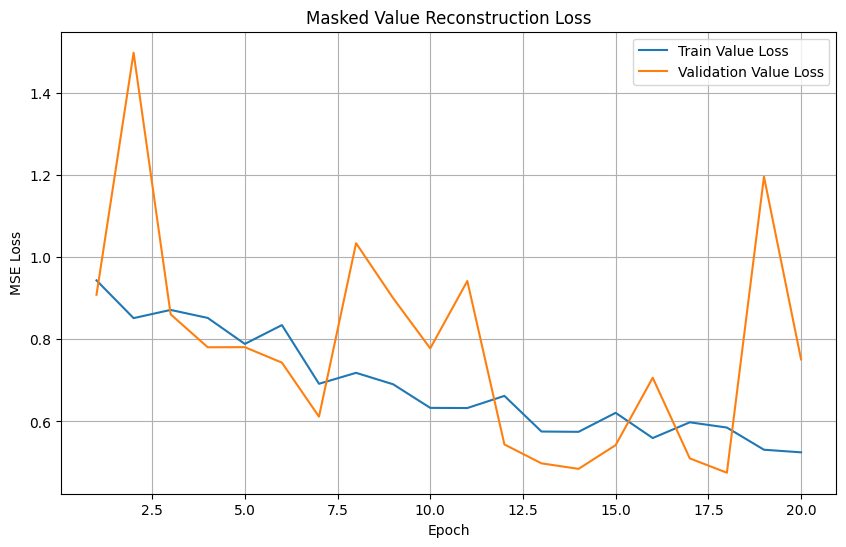

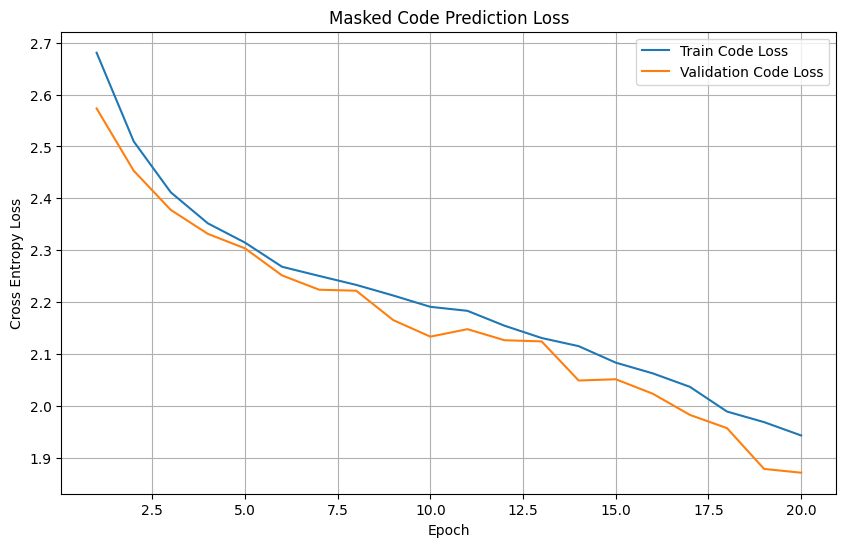

In [ ]:

# Plot Graphs

import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

# ---- Total Loss ----
plt.figure(figsize=(10, 6))

plt.plot(epochs_range, train_losses, label="Train Total Loss")
plt.plot(epochs_range, val_losses, label="Validation Total Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Total Loss vs Epoch")
plt.legend()
plt.grid(True)

plt.show()

# Value Loss 
plt.figure(figsize=(10, 6))

plt.plot(epochs_range, train_value_losses, label="Train Value Loss")
plt.plot(epochs_range, val_value_losses, label="Validation Value Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Masked Value Reconstruction Loss")
plt.legend()
plt.grid(True)

plt.show()

# Code Loss
plt.figure(figsize=(10, 6))

plt.plot(epochs_range, train_code_losses, label="Train Code Loss")
plt.plot(epochs_range, val_code_losses, label="Validation Code Loss")

plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Masked Code Prediction Loss")
plt.legend()
plt.grid(True)

plt.show()

### Baseline Model Comparison

To establish a performance floor for the evaluation, we implemented a **Global Mean Imputation** baseline. This approach assumes that the best estimate for any missing observation is simply the average of all historical data.

---

#### Implementation Methodology

The baseline was constructed through the following steps:

*   **Global Mean Calculation**: We aggregated all lab results and vital sign measurements from the **training set** to calculate a single global mean value ($\mu$) for each feature.
*   **Validation Masking**: During the validation phase, we simulated missing data by **randomly masking** a subset of the actual values.
*   **Constant Imputation**: Every masked value was replaced with the constant global mean prediction.
    *   $\hat{y} = \bar{y}_{train}$
*   **Performance Evaluation**: We computed the **Mean Squared Error (MSE)** between these static predictions and the actual ground-truth values to determine the baseline error rate.

#### Baseline Formula
The error was measured using the standard MSE formula:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_{i} - \hat{y}_{i})^2$$

> **Note:** This baseline serves as a "sanity check." Any proposed model must achieve an MSE significantly lower than this value to demonstrate that it has learned meaningful patterns beyond simple averages.


In [95]:
import torch
import torch.nn.functional as F

# Calculate global mean value from training data only
all_train_values = []

for batch in train_loader:
    code_id, value, delta, attn_mask = batch
    mask = attn_mask == 1
    all_train_values.append(value[mask])

all_train_values = torch.cat(all_train_values, dim=0)

global_mean_value = all_train_values.mean(dim=0)

print("Global mean value:", global_mean_value)

Global mean value: tensor([ 0.0013, -0.0029,  0.0052, -0.0138])


In [96]:
baseline_total_mse = 0
num_batches = 0

with torch.no_grad():
    for batch in val_loader:
        code_id, value, delta, attn_mask = batch

        B, L = code_id.shape

        value_mask = torch.zeros((B, L), dtype=torch.bool)

        for b in range(B):
            valid_idx = torch.where(attn_mask[b] == 1)[0].tolist()

            if len(valid_idx) == 0:
                continue

            k_value = max(1, int(len(valid_idx) * value_mask_prob))
            value_chosen = random.sample(valid_idx, k_value)
            value_mask[b, value_chosen] = True

        baseline_pred = global_mean_value.view(1, 1, 4).expand(B, L, 4)

        baseline_loss = F.mse_loss(
            baseline_pred[value_mask],
            value[value_mask]
        )

        baseline_total_mse += baseline_loss.item()
        num_batches += 1

avg_baseline_mse = baseline_total_mse / num_batches

print("Baseline Validation MSE:", avg_baseline_mse)
print("Your Transformer Best Val Value MSE:", 0.475097)

Baseline Validation MSE: 0.8817195693651835
Your Transformer Best Val Value MSE: 0.475097


#### Generating embeddings (size 128) and converting them to csv

In [98]:
import torch
import pandas as pd
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best model
model.load_state_dict(torch.load("best_aim1_transformer.pt", map_location=device))
model.to(device)
model.eval()

embed_loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False
)

all_embeddings = []

with torch.no_grad():
    for batch in embed_loader:
        code_ids, values, deltas, masks = [b.to(device) for b in batch]

        # Use model forward directly
        pred_vals, pred_codes, h = model(
            code_ids,
            values,
            deltas,
            masks
        )

        # Mean pooling over real tokens only
        mask_expanded = masks.unsqueeze(-1).float()

        summed = (h * mask_expanded).sum(dim=1)
        counts = mask_expanded.sum(dim=1).clamp(min=1)

        patient_embedding = summed / counts

        all_embeddings.append(patient_embedding.cpu())

all_embeddings = torch.cat(all_embeddings, dim=0)

print("Embedding shape:", all_embeddings.shape)

embedding_df = pd.DataFrame(
    all_embeddings.numpy(),
    columns=[f"emb_{i}" for i in range(all_embeddings.shape[1])]
)

# Add patient IDs if you have them
# embedding_df.insert(0, "patient_id", patient_ids)

embedding_df.to_csv("aim1_patient_embeddings_final.csv", index=False)

print("Saved aim1_patient_embeddings_final.csv")

Embedding shape: torch.Size([2336, 128])
Saved aim1_patient_embeddings_final.csv


In [78]:
best_loss = float("inf")

# inside epoch loop, after avg_loss
if avg_loss < best_loss:
    best_loss = avg_loss
    torch.save(model.state_dict(), "best_aim1_value_codeid_transformer.pt")
    print("Saved best model")

Saved best model


In [ ]:
model.eval() 
all_embeddings = []

with torch.no_grad():
    for batch in loader:
        codes, values, deltas, masks = [b.to(device) for b in batch]
        
        x = model.code_emb(codes) + model.delta_emb(deltas) + model.val_proj(values)
              
        x = model.layer_norm(x) 
               
        h = model.encoder(x, src_key_padding_mask=(masks == 0))
        
        mask_expanded = masks.unsqueeze(-1).float()
        pooled_h = torch.sum(h * mask_expanded, dim=1) / torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        
        all_embeddings.append(pooled_h.cpu())

# Combine into the final matrix
patient_embeddings = torch.cat(all_embeddings, dim=0)
print("Embedding Matrix Shape:", patient_embeddings.shape)

c:\Users\abhir\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Embedding Matrix Shape: torch.Size([2336, 128])


#### Using t-SNE visualization to visualize the embeddings and applied k-means clustering on them

Embedding Shape: (2336, 128)
Cluster Labels Shape: (2336,)
Silhouette Score: 0.3242530933217424


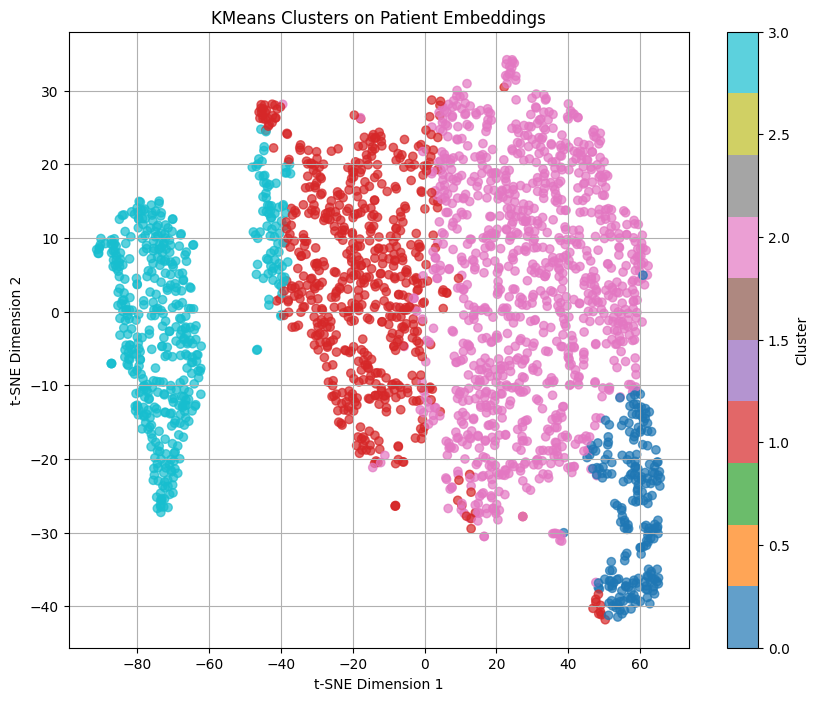

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score


# Load embeddings
embedding_df = pd.read_csv("aim1_patient_embeddings_final.csv")

X = embedding_df.values

print("Embedding Shape:", X.shape)


# Run KMeans Clustering
n_clusters = 4

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X)

print("Cluster Labels Shape:", cluster_labels.shape)


# Silhouette Score
sil_score = silhouette_score(X, cluster_labels)

print("Silhouette Score:", sil_score)

# Run t-SNE for visualization

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42,
    init="pca"
)

X_tsne = tsne.fit_transform(X)


plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=cluster_labels,
    cmap="tab10",
    alpha=0.7
)

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.title("KMeans Clusters on Patient Embeddings")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)

plt.show()

#### Experiment 2- Masking only code_ids
##### Learns semantic relationships between diagnoses, medications, and labs


In [116]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt

from torch.utils.data import random_split, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [112]:
class TimeSeriesTransformer(nn.Module):
    def __init__(
        self,
        num_codes,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_ff=256,
        dropout=0.1,
        max_delta_days=365
    ):
        super().__init__()

        self.max_delta_days = max_delta_days

        # Input embeddings
        self.code_emb = nn.Embedding(
            num_codes + 1,
            d_model,
            padding_idx=0
        )

        self.delta_emb = nn.Embedding(
            max_delta_days + 1,
            d_model
        )

        self.val_proj = nn.Linear(4, d_model)

        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Code prediction head only
        self.code_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, num_codes + 1)
        )

    def forward(self, code_ids, values, delta_days, attn_mask):
        delta_days = torch.clamp(
            delta_days,
            0,
            self.max_delta_days
        )

        x = (
            self.code_emb(code_ids) +
            self.delta_emb(delta_days) +
            self.val_proj(values)
        )

        x = self.dropout(self.layer_norm(x))

        padding_mask = attn_mask == 0

        h = self.encoder(
            x,
            src_key_padding_mask=padding_mask
        )

        pred_codes = self.code_head(h)

        return pred_codes, h

In [113]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TimeSeriesTransformer(
    num_codes=num_codes,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_ff=256,
    dropout=0.1
)

model.to(device)

TimeSeriesTransformer(
  (code_emb): Embedding(17, 128, padding_idx=0)
  (delta_emb): Embedding(366, 128)
  (val_proj): Linear(in_features=4, out_features=128, bias=True)
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (code_hea

In [114]:
total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Train patients:", len(train_dataset))
print("Validation patients:", len(val_dataset))

Train patients: 1868
Validation patients: 468


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

mask_prob = 0.15
epochs = 20

best_val_loss = float("inf")

train_losses = []
val_losses = []

val_acc_list = []
val_precision_list = []
val_recall_list = []
val_f1_list = []

print(f"Starting masked code_id pretraining on {device}...")

for epoch in range(epochs):

  
    # Training
   
    model.train()

    total_train_loss = 0

    for batch in train_loader:
        code_id, value, delta, attn_mask = [b.to(device) for b in batch]

        B, L = code_id.shape

        code_mask = torch.zeros(
            (B, L),
            dtype=torch.bool,
            device=device
        )

        for b in range(B):
            valid_idx = torch.where(attn_mask[b] == 1)[0].tolist()

            if len(valid_idx) == 0:
                continue

            k = max(1, int(len(valid_idx) * mask_prob))
            chosen = random.sample(valid_idx, k)

            code_mask[b, chosen] = True

        code_in = code_id.clone()

        # Mask only code_ids
        code_in[code_mask] = 0

        optimizer.zero_grad()

        pred_codes, h = model(
            code_in,
            value,
            delta,
            attn_mask
        )

        loss = F.cross_entropy(
            pred_codes[code_mask],
            code_id[code_mask]
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)

  
    # Validation
  
    model.eval()

    total_val_loss = 0

    all_true_codes = []
    all_pred_codes = []

    with torch.no_grad():
        for batch in val_loader:
            code_id, value, delta, attn_mask = [b.to(device) for b in batch]

            B, L = code_id.shape

            code_mask = torch.zeros(
                (B, L),
                dtype=torch.bool,
                device=device
            )

            for b in range(B):
                valid_idx = torch.where(attn_mask[b] == 1)[0].tolist()

                if len(valid_idx) == 0:
                    continue

                k = max(1, int(len(valid_idx) * mask_prob))
                chosen = random.sample(valid_idx, k)

                code_mask[b, chosen] = True

            code_in = code_id.clone()
            code_in[code_mask] = 0

            pred_codes, h = model(
                code_in,
                value,
                delta,
                attn_mask
            )

            val_loss = F.cross_entropy(
                pred_codes[code_mask],
                code_id[code_mask]
            )

            total_val_loss += val_loss.item()

            pred_classes = pred_codes[code_mask].argmax(dim=-1)

            all_true_codes.extend(
                code_id[code_mask].cpu().numpy()
            )

            all_pred_codes.extend(
                pred_classes.cpu().numpy()
            )

    avg_val_loss = total_val_loss / len(val_loader)

    val_acc = accuracy_score(
        all_true_codes,
        all_pred_codes
    )

    val_precision = precision_score(
        all_true_codes,
        all_pred_codes,
        average="weighted",
        zero_division=0
    )

    val_recall = recall_score(
        all_true_codes,
        all_pred_codes,
        average="weighted",
        zero_division=0
    )

    val_f1 = f1_score(
        all_true_codes,
        all_pred_codes,
        average="weighted",
        zero_division=0
    )

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    val_acc_list.append(val_acc)
    val_precision_list.append(val_precision)
    val_recall_list.append(val_recall)
    val_f1_list.append(val_f1)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f} | "
        f"Acc: {val_acc:.4f} | "
        f"Precision: {val_precision:.4f} | "
        f"Recall: {val_recall:.4f} | "
        f"F1: {val_f1:.4f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            "best_masked_code_transformer.pt"
        )

        print("Saved best masked-code model")

print("Masked code_id pretraining finished.")
print(f"Best Validation Loss: {best_val_loss:.6f}")

Starting masked code_id pretraining on cpu...
Epoch [1/20] Train Loss: 2.411852 | Val Loss: 2.335297 | Acc: 0.2214 | Precision: 0.2009 | Recall: 0.2214 | F1: 0.1469
Saved best masked-code model
Epoch [2/20] Train Loss: 2.304271 | Val Loss: 2.258983 | Acc: 0.2445 | Precision: 0.2147 | Recall: 0.2445 | F1: 0.1835
Saved best masked-code model
Epoch [3/20] Train Loss: 2.244660 | Val Loss: 2.184935 | Acc: 0.2629 | Precision: 0.2182 | Recall: 0.2629 | F1: 0.2088
Saved best masked-code model
Epoch [4/20] Train Loss: 2.159693 | Val Loss: 2.130873 | Acc: 0.2890 | Precision: 0.2421 | Recall: 0.2890 | F1: 0.2435
Saved best masked-code model
Epoch [5/20] Train Loss: 2.086321 | Val Loss: 2.008597 | Acc: 0.3283 | Precision: 0.3040 | Recall: 0.3283 | F1: 0.2850
Saved best masked-code model
Epoch [6/20] Train Loss: 1.974208 | Val Loss: 1.910715 | Acc: 0.3583 | Precision: 0.3263 | Recall: 0.3583 | F1: 0.3226
Saved best masked-code model
Epoch [7/20] Train Loss: 1.881262 | Val Loss: 1.818128 | Acc: 0.39

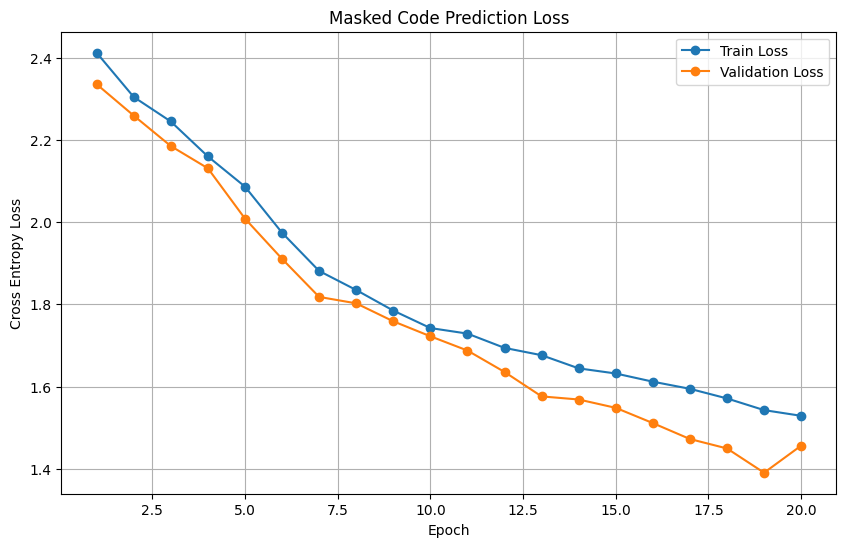

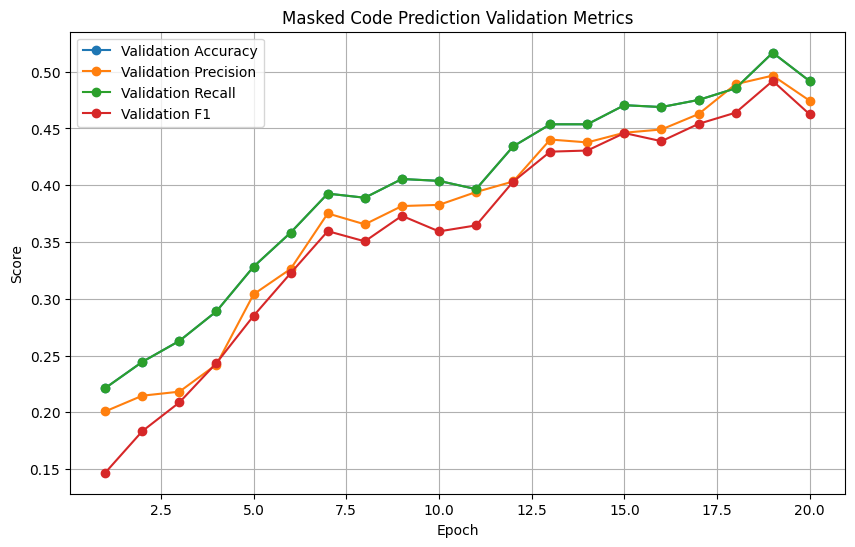

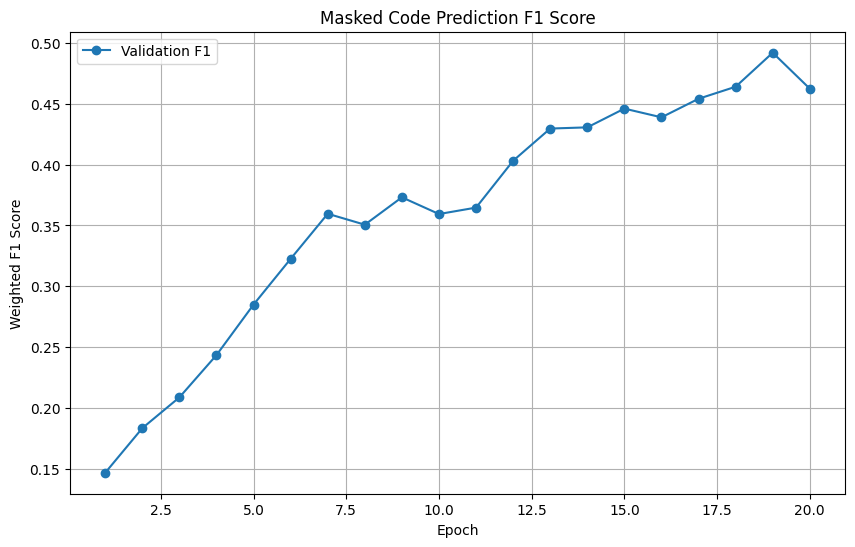

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)


# Train vs Validation Loss

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, train_losses, marker="o", label="Train Loss")
plt.plot(epochs_range, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Masked Code Prediction Loss")
plt.legend()
plt.grid(True)
plt.show()



# Accuracy, Precision, Recall, F1

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_acc_list, marker="o", label="Validation Accuracy")
plt.plot(epochs_range, val_precision_list, marker="o", label="Validation Precision")
plt.plot(epochs_range, val_recall_list, marker="o", label="Validation Recall")
plt.plot(epochs_range, val_f1_list, marker="o", label="Validation F1")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Masked Code Prediction Validation Metrics")
plt.legend()
plt.grid(True)
plt.show()


# 3. F1 

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, val_f1_list, marker="o", label="Validation F1")

plt.xlabel("Epoch")
plt.ylabel("Weighted F1 Score")
plt.title("Masked Code Prediction F1 Score")
plt.legend()
plt.grid(True)
plt.show()

#### Experiment 3 - Masking the same value and code_id and ask the model to predict it
##### Tests the model’s ability to reconstruct highly missing events

In [123]:
class TimeSeriesTransformer(nn.Module):
    def __init__(
        self,
        num_codes,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_ff=256,
        dropout=0.1,
        max_delta_days=365
    ):
        super().__init__()

        self.max_delta_days = max_delta_days

        # Embeddings
        self.code_emb = nn.Embedding(
            num_codes + 1,
            d_model,
            padding_idx=0
        )

        self.delta_emb = nn.Embedding(
            max_delta_days + 1,
            d_model
        )

        self.val_proj = nn.Linear(4, d_model)

        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Value reconstruction head
        self.value_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 4)
        )

        # Code prediction head
        self.code_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, num_codes + 1)
        )

    def forward(
        self,
        code_ids,
        values,
        delta_days,
        attn_mask
    ):

        delta_days = torch.clamp(
            delta_days,
            0,
            self.max_delta_days
        )

        x = (
            self.code_emb(code_ids) +
            self.delta_emb(delta_days) +
            self.val_proj(values)
        )

        x = self.dropout(
            self.layer_norm(x)
        )

        padding_mask = attn_mask == 0

        h = self.encoder(
            x,
            src_key_padding_mask=padding_mask
        )

        pred_values = self.value_head(h)
        pred_codes = self.code_head(h)

        return pred_values, pred_codes, h

In [124]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = TimeSeriesTransformer(
    num_codes=num_codes,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_ff=256,
    dropout=0.1
)

model.to(device)

TimeSeriesTransformer(
  (code_emb): Embedding(17, 128, padding_idx=0)
  (delta_emb): Embedding(366, 128)
  (val_proj): Linear(in_features=4, out_features=128, bias=True)
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (value_he

In [125]:
total_size = len(dataset)

train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

print("Train patients:", len(train_dataset))
print("Validation patients:", len(val_dataset))

Train patients: 1868
Validation patients: 468


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

mask_prob = 0.15
code_loss_weight = 0.1
epochs = 20

best_val_loss = float("inf")

train_total_losses = []
val_total_losses = []

train_value_losses = []
val_value_losses = []

train_code_losses = []
val_code_losses = []

val_acc_list = []
val_precision_list = []
val_recall_list = []
val_f1_list = []

print(f"Starting joint masked value+code pretraining on {device}...")

for epoch in range(epochs):

   
    # TRAINING
  
    model.train()

    total_loss = 0
    total_value_loss = 0
    total_code_loss = 0

    for batch in train_loader:

        code_id, value, delta, attn_mask = [
            b.to(device) for b in batch
        ]

        B, L = code_id.shape

        # SAME mask for value + code
        joint_mask = torch.zeros(
            (B, L),
            dtype=torch.bool,
            device=device
        )

        for b in range(B):

            valid_idx = torch.where(
                attn_mask[b] == 1
            )[0].tolist()

            if len(valid_idx) == 0:
                continue

            k = max(
                1,
                int(len(valid_idx) * mask_prob)
            )

            chosen = random.sample(valid_idx, k)

            joint_mask[b, chosen] = True

        # Mask BOTH code and value
        code_in = code_id.clone()
        value_in = value.clone()

        code_in[joint_mask] = 0
        value_in[joint_mask] = 0.0

        optimizer.zero_grad()

        pred_values, pred_codes, h = model(
            code_in,
            value_in,
            delta,
            attn_mask
        )

        # Value reconstruction
        loss_value = F.mse_loss(
            pred_values[joint_mask],
            value[joint_mask]
        )

        # Code prediction
        loss_code = F.cross_entropy(
            pred_codes[joint_mask],
            code_id[joint_mask]
        )

        # Combined loss
        loss = (
            loss_value +
            code_loss_weight * loss_code
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )

        optimizer.step()

        total_loss += loss.item()
        total_value_loss += loss_value.item()
        total_code_loss += loss_code.item()

    avg_train_loss = total_loss / len(train_loader)
    avg_train_value_loss = total_value_loss / len(train_loader)
    avg_train_code_loss = total_code_loss / len(train_loader)

  
    # VALIDATION
  
    model.eval()

    val_total_loss = 0
    val_value_loss = 0
    val_code_loss = 0

    all_true_codes = []
    all_pred_codes = []

    with torch.no_grad():

        for batch in val_loader:

            code_id, value, delta, attn_mask = [
                b.to(device) for b in batch
            ]

            B, L = code_id.shape

            joint_mask = torch.zeros(
                (B, L),
                dtype=torch.bool,
                device=device
            )

            for b in range(B):

                valid_idx = torch.where(
                    attn_mask[b] == 1
                )[0].tolist()

                if len(valid_idx) == 0:
                    continue

                k = max(
                    1,
                    int(len(valid_idx) * mask_prob)
                )

                chosen = random.sample(valid_idx, k)

                joint_mask[b, chosen] = True

            code_in = code_id.clone()
            value_in = value.clone()

            code_in[joint_mask] = 0
            value_in[joint_mask] = 0.0

            pred_values, pred_codes, h = model(
                code_in,
                value_in,
                delta,
                attn_mask
            )

            loss_value = F.mse_loss(
                pred_values[joint_mask],
                value[joint_mask]
            )

            loss_code = F.cross_entropy(
                pred_codes[joint_mask],
                code_id[joint_mask]
            )

            val_loss = (
                loss_value +
                code_loss_weight * loss_code
            )

            val_total_loss += val_loss.item()
            val_value_loss += loss_value.item()
            val_code_loss += loss_code.item()

            pred_classes = pred_codes[
                joint_mask
            ].argmax(dim=-1)

            all_true_codes.extend(
                code_id[joint_mask].cpu().numpy()
            )

            all_pred_codes.extend(
                pred_classes.cpu().numpy()
            )

    avg_val_loss = val_total_loss / len(val_loader)
    avg_val_value_loss = val_value_loss / len(val_loader)
    avg_val_code_loss = val_code_loss / len(val_loader)

    # Metrics
    val_acc = accuracy_score(
        all_true_codes,
        all_pred_codes
    )

    val_precision = precision_score(
        all_true_codes,
        all_pred_codes,
        average="weighted",
        zero_division=0
    )

    val_recall = recall_score(
        all_true_codes,
        all_pred_codes,
        average="weighted",
        zero_division=0
    )

    val_f1 = f1_score(
        all_true_codes,
        all_pred_codes,
        average="weighted",
        zero_division=0
    )

    # Store history
    train_total_losses.append(avg_train_loss)
    val_total_losses.append(avg_val_loss)

    train_value_losses.append(avg_train_value_loss)
    val_value_losses.append(avg_val_value_loss)

    train_code_losses.append(avg_train_code_loss)
    val_code_losses.append(avg_val_code_loss)

    val_acc_list.append(val_acc)
    val_precision_list.append(val_precision)
    val_recall_list.append(val_recall)
    val_f1_list.append(val_f1)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Total: {avg_train_loss:.6f} | "
        f"Train Value: {avg_train_value_loss:.6f} | "
        f"Train Code: {avg_train_code_loss:.6f} || "
        f"Val Total: {avg_val_loss:.6f} | "
        f"Val Value: {avg_val_value_loss:.6f} | "
        f"Val Code: {avg_val_code_loss:.6f} | "
        f"Acc: {val_acc:.4f} | "
        f"F1: {val_f1:.4f}"
    )

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            "best_joint_mask_transformer.pt"
        )

        print("Saved best joint-mask model")

print("Joint masked value+code pretraining finished.")
print(f"Best Validation Loss: {best_val_loss:.6f}")

Starting joint masked value+code pretraining on cpu...
Epoch [1/20] Train Total: 1.210663 | Train Value: 0.941657 | Train Code: 2.690059 || Val Total: 1.569983 | Val Value: 1.316235 | Val Code: 2.537478 | Acc: 0.1867 | F1: 0.1151
Saved best joint-mask model
Epoch [2/20] Train Total: 1.087523 | Train Value: 0.837785 | Train Code: 2.497383 || Val Total: 1.041835 | Val Value: 0.799890 | Val Code: 2.419452 | Acc: 0.2174 | F1: 0.1447
Saved best joint-mask model
Epoch [3/20] Train Total: 1.044076 | Train Value: 0.804277 | Train Code: 2.397992 || Val Total: 1.110150 | Val Value: 0.872934 | Val Code: 2.372162 | Acc: 0.2105 | F1: 0.1380
Epoch [4/20] Train Total: 1.084256 | Train Value: 0.850324 | Train Code: 2.339322 || Val Total: 1.205398 | Val Value: 0.973835 | Val Code: 2.315632 | Acc: 0.2148 | F1: 0.1502
Epoch [5/20] Train Total: 1.086217 | Train Value: 0.853465 | Train Code: 2.327529 || Val Total: 1.821910 | Val Value: 1.588779 | Val Code: 2.331311 | Acc: 0.2194 | F1: 0.1536
Epoch [6/20] T

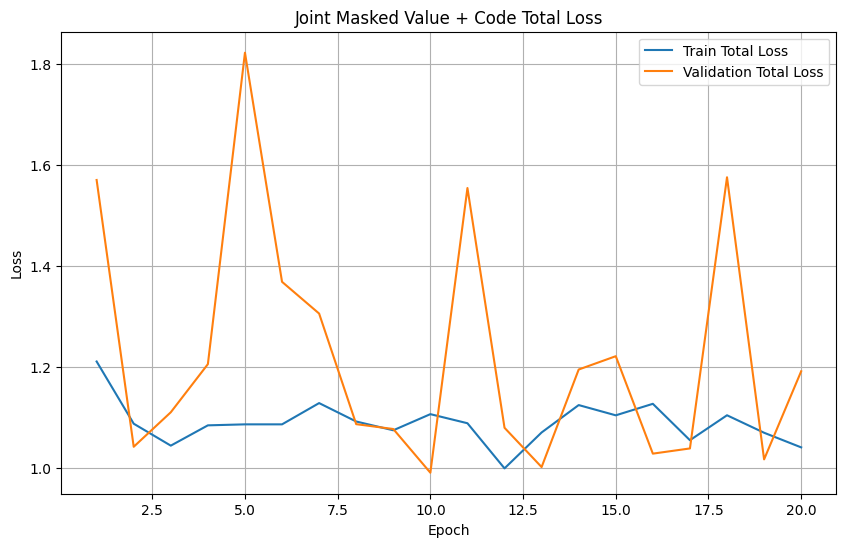

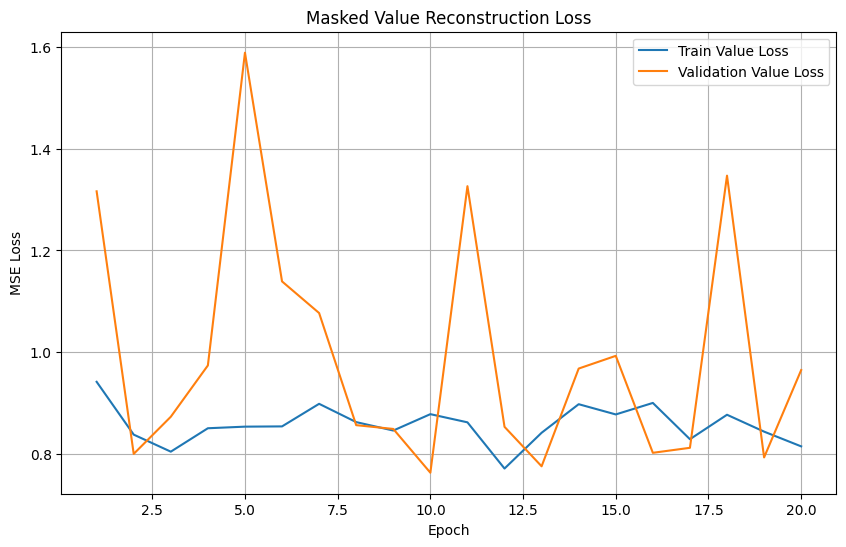

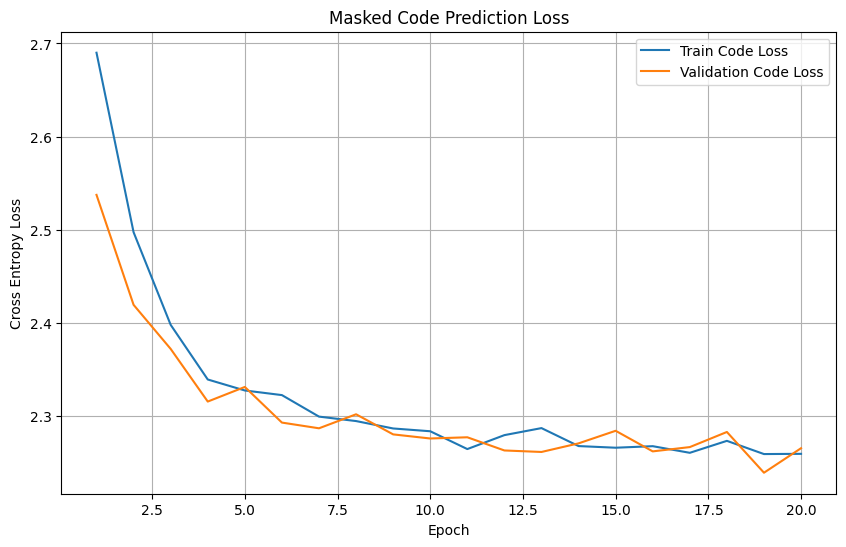

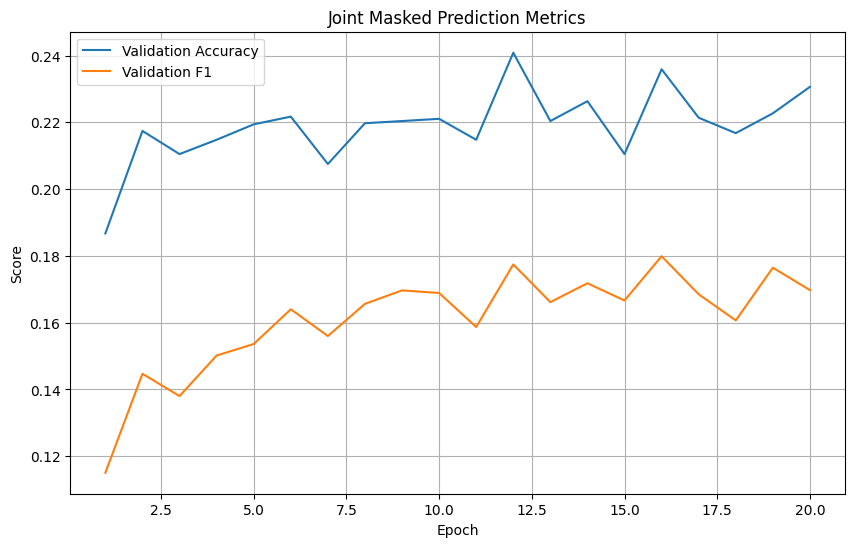

In [ ]:
epochs_range = range(1, epochs + 1)


# Total Loss

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_total_losses,
    label="Train Total Loss"
)

plt.plot(
    epochs_range,
    val_total_losses,
    label="Validation Total Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Joint Masked Value + Code Total Loss")

plt.legend()
plt.grid(True)
plt.show()


# Value Loss

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_value_losses,
    label="Train Value Loss"
)

plt.plot(
    epochs_range,
    val_value_losses,
    label="Validation Value Loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Masked Value Reconstruction Loss")

plt.legend()
plt.grid(True)
plt.show()



# Code Loss

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    train_code_losses,
    label="Train Code Loss"
)

plt.plot(
    epochs_range,
    val_code_losses,
    label="Validation Code Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title("Masked Code Prediction Loss")

plt.legend()
plt.grid(True)
plt.show()



# Accuracy / F1

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    val_acc_list,
    label="Validation Accuracy"
)

plt.plot(
    epochs_range,
    val_f1_list,
    label="Validation F1"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Joint Masked Prediction Metrics")

plt.legend()
plt.grid(True)
plt.show()

#### Experiment 4 - Masking an entire event and ask the model to predict it

##### Masked the entire clinical event including medical code, numerical value, temporal gap. Learns integrated temporal, semantic, and numerical patient representations


In [109]:
import torch
import torch.nn as nn

class TimeSeriesTransformer(nn.Module):
    def __init__(self, num_codes, d_model=128, nhead=4, num_layers=2,
                 dim_ff=256, dropout=0.1, max_delta_days=365):
        super().__init__()

        self.max_delta_days = max_delta_days

        self.code_emb = nn.Embedding(num_codes + 1, d_model, padding_idx=0)
        self.delta_emb = nn.Embedding(max_delta_days + 1, d_model)
        self.val_proj = nn.Linear(4, d_model)

        self.layer_norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation="gelu"
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # Predict values [mean, max, min, count]
        self.value_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 4)
        )

        # Predict code_id
        self.code_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, num_codes + 1)
        )

        # Predict delta_days
        self.delta_head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, 1)
        )

    def forward(self, code_ids, values, delta_days, attn_mask):
        delta_days = torch.clamp(delta_days, 0, self.max_delta_days)

        x = (
            self.code_emb(code_ids) +
            self.delta_emb(delta_days) +
            self.val_proj(values)
        )

        x = self.dropout(self.layer_norm(x))

        padding_mask = attn_mask == 0

        h = self.encoder(
            x,
            src_key_padding_mask=padding_mask
        )

        pred_values = self.value_head(h)
        pred_codes = self.code_head(h)
        pred_delta = self.delta_head(h).squeeze(-1)

        return pred_values, pred_codes, pred_delta, h

       

In [110]:
model = TimeSeriesTransformer(
    num_codes=num_codes,
    d_model=128,
    nhead=4,
    num_layers=2,
    dim_ff=256,
    dropout=0.1
)

model.to(device)

TimeSeriesTransformer(
  (code_emb): Embedding(17, 128, padding_idx=0)
  (delta_emb): Embedding(366, 128)
  (val_proj): Linear(in_features=4, out_features=128, bias=True)
  (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (value_he

In [ ]:
import torch
import torch.nn.functional as F
import random
from torch.utils.data import random_split, DataLoader


# Train / validation split

total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Train patients:", len(train_dataset))
print("Validation patients:", len(val_dataset))


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

event_mask_prob = 0.15
code_loss_weight = 0.1
delta_loss_weight = 0.01
epochs = 20

best_val_loss = float("inf")

train_losses = []
val_losses = []

train_value_losses = []
val_value_losses = []

train_code_losses = []
val_code_losses = []

train_delta_losses = []
val_delta_losses = []

print(f"Starting full masked-event pretraining on {device}...")


# Training

for epoch in range(epochs):
    model.train()

    total_loss = 0
    total_value_loss = 0
    total_code_loss = 0
    total_delta_loss = 0

    for batch in train_loader:
        code_id, value, delta, attn_mask = [b.to(device) for b in batch]

        B, L = code_id.shape

        event_mask = torch.zeros((B, L), dtype=torch.bool, device=device)

        for b in range(B):
            valid_idx = torch.where(attn_mask[b] == 1)[0].tolist()

            if len(valid_idx) == 0:
                continue

            k = max(1, int(len(valid_idx) * event_mask_prob))
            chosen = random.sample(valid_idx, k)
            event_mask[b, chosen] = True

        # Mask full event: code + value + delta
        code_in = code_id.clone()
        value_in = value.clone()
        delta_in = delta.clone()

        code_in[event_mask] = 0
        value_in[event_mask] = 0.0
        delta_in[event_mask] = 0

        optimizer.zero_grad()

        pred_values, pred_codes, pred_delta, h = model(
            code_in,
            value_in,
            delta_in,
            attn_mask
        )

        # Value reconstruction loss
        loss_value = F.mse_loss(
            pred_values[event_mask],
            value[event_mask]
        )

        # Code prediction loss
        loss_code = F.cross_entropy(
            pred_codes[event_mask],
            code_id[event_mask]
        )

        # Delta-time prediction loss
        target_delta = torch.log1p(delta.float())

        loss_delta = F.mse_loss(pred_delta[event_mask],target_delta[event_mask])

        loss = (
            loss_value
            + code_loss_weight * loss_code
            + delta_loss_weight * loss_delta
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        total_value_loss += loss_value.item()
        total_code_loss += loss_code.item()
        total_delta_loss += loss_delta.item()

    avg_train_loss = total_loss / len(train_loader)
    avg_train_value_loss = total_value_loss / len(train_loader)
    avg_train_code_loss = total_code_loss / len(train_loader)
    avg_train_delta_loss = total_delta_loss / len(train_loader)


    # Validation
 
    model.eval()

    val_total_loss = 0
    val_value_loss = 0
    val_code_loss = 0
    val_delta_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            code_id, value, delta, attn_mask = [b.to(device) for b in batch]

            B, L = code_id.shape

            event_mask = torch.zeros((B, L), dtype=torch.bool, device=device)

            for b in range(B):
                valid_idx = torch.where(attn_mask[b] == 1)[0].tolist()

                if len(valid_idx) == 0:
                    continue

                k = max(1, int(len(valid_idx) * event_mask_prob))
                chosen = random.sample(valid_idx, k)
                event_mask[b, chosen] = True

            code_in = code_id.clone()
            value_in = value.clone()
            delta_in = delta.clone()

            code_in[event_mask] = 0
            value_in[event_mask] = 0.0
            delta_in[event_mask] = 0

            pred_values, pred_codes, pred_delta, h = model(
                code_in,
                value_in,
                delta_in,
                attn_mask
            )

            loss_value = F.mse_loss(
                pred_values[event_mask],
                value[event_mask]
            )

            loss_code = F.cross_entropy(
                pred_codes[event_mask],
                code_id[event_mask]
            )

            target_delta = torch.log1p(delta.float())
            loss_delta = F.mse_loss(  pred_delta[event_mask],   target_delta[event_mask])

            val_loss = (
                loss_value
                + code_loss_weight * loss_code
                + delta_loss_weight * loss_delta
            )

            val_total_loss += val_loss.item()
            val_value_loss += loss_value.item()
            val_code_loss += loss_code.item()
            val_delta_loss += loss_delta.item()

    avg_val_loss = val_total_loss / len(val_loader)
    avg_val_value_loss = val_value_loss / len(val_loader)
    avg_val_code_loss = val_code_loss / len(val_loader)
    avg_val_delta_loss = val_delta_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    train_value_losses.append(avg_train_value_loss)
    val_value_losses.append(avg_val_value_loss)

    train_code_losses.append(avg_train_code_loss)
    val_code_losses.append(avg_val_code_loss)

    train_delta_losses.append(avg_train_delta_loss)
    val_delta_losses.append(avg_val_delta_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Value: {avg_train_value_loss:.6f} | "
        f"Code: {avg_train_code_loss:.6f} | "
        f"Delta: {avg_train_delta_loss:.6f} || "
        f"Val Loss: {avg_val_loss:.6f} | "
        f"Val Value: {avg_val_value_loss:.6f} | "
        f"Val Code: {avg_val_code_loss:.6f} | "
        f"Val Delta: {avg_val_delta_loss:.6f}"
    )

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_full_event_transformer.pt")
        print("Saved best full-event model")

print("Full masked-event pretraining finished.")
print(f"Best Validation Loss: {best_val_loss:.6f}")

Train patients: 1868
Validation patients: 468
Starting full masked-event pretraining on cpu...
Epoch [1/20] Train Loss: 1.196553 | Value: 0.918445 | Code: 2.695137 | Delta: 0.859452 || Val Loss: 1.756141 | Val Value: 1.488849 | Val Code: 2.591531 | Val Delta: 0.813903
Saved best full-event model
Epoch [2/20] Train Loss: 1.261056 | Value: 0.996021 | Code: 2.565942 | Delta: 0.844029 || Val Loss: 1.141502 | Val Value: 0.880031 | Val Code: 2.540142 | Val Delta: 0.745669
Saved best full-event model
Epoch [3/20] Train Loss: 1.103686 | Value: 0.841703 | Code: 2.538858 | Delta: 0.809676 || Val Loss: 1.218842 | Val Value: 0.959123 | Val Code: 2.528567 | Val Delta: 0.686210
Epoch [4/20] Train Loss: 1.110350 | Value: 0.849546 | Code: 2.523521 | Delta: 0.845206 || Val Loss: 1.617423 | Val Value: 1.358044 | Val Code: 2.517498 | Val Delta: 0.762983
Epoch [5/20] Train Loss: 1.115951 | Value: 0.855988 | Code: 2.513685 | Delta: 0.859414 || Val Loss: 1.307187 | Val Value: 1.046850 | Val Code: 2.531844 |